# ai_videogames · Reto evaluable PRO
## Transfer Learning para criaturas RPG

### Objetivo
Construir un clasificador de criaturas inspirado en RPG usando **Oxford-IIIT Pet** y una arquitectura preentrenada.

### Metas orientativas
- **Accuracy ≥ 0.80** en fase 1
- **Accuracy ≥ 0.85** tras fine-tuning

> No son obligatorias si tu análisis es bueno, pero sirven como referencia.


In [12]:
pip install tensorflow tensorflow-datasets matplotlib

In [13]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True
)

label_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes
print("Clases:", num_classes)

Clases: 37


## 1) Preprocesado
Completa el pipeline de datos y documenta brevemente qué hace cada paso.


In [14]:
# TODO: elige preprocess_input según tu arquitectura
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label

train_ds = (
    ds_train_raw
    .shuffle(2000, seed=SEED)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

## 2) Data augmentation
Añade al menos 2 transformaciones y justifícalas en una celda markdown.


In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

## 3) Fase 1 · Feature extraction
Usa una base preentrenada y congélala.
Sugerencias:
- MobileNetV2
- EfficientNetB0
- ResNet50


In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )
]

history_1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 105ms/step - accuracy: 0.5530 - loss: 1.6723 - val_accuracy: 0.8111 - val_loss: 0.6866
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.8342 - loss: 0.5713 - val_accuracy: 0.8302 - val_loss: 0.5348
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.8692 - loss: 0.4144 - val_accuracy: 0.8573 - val_loss: 0.4512
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.8978 - loss: 0.3277 - val_accuracy: 0.8668 - val_loss: 0.4138
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9205 - loss: 0.2651 - val_accuracy: 0.8614 - val_loss: 0.4037


## 4) Fase 2 · Fine-tuning
Desbloquea parcialmente la base y vuelve a entrenar con learning rate más bajo.


In [17]:
base_model.trainable = True

# TODO: puedes experimentar con este corte
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=8,
    initial_epoch=history_1.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.7826 - loss: 0.7280 - val_accuracy: 0.8668 - val_loss: 0.4025
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.8349 - loss: 0.5512 - val_accuracy: 0.8668 - val_loss: 0.4011


## 5) Curvas de entrenamiento
Representa:
- accuracy train
- accuracy validación
- marca el punto donde empieza el fine-tuning


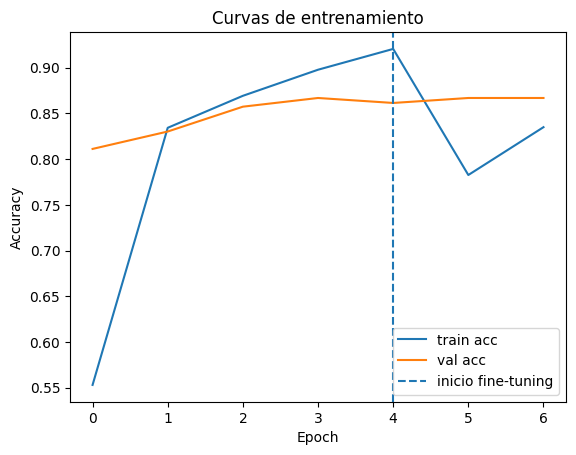

In [18]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

plt.figure()
plt.plot(acc, label="train acc")
plt.plot(val_acc, label="val acc")
plt.axvline(x=len(history_1.history["accuracy"])-1, linestyle="--", label="inicio fine-tuning")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de entrenamiento")
plt.show()

## 6) Evaluación cuantitativa
Reporta accuracy final y compárala con tus objetivos.


In [19]:
loss, acc = model.evaluate(test_ds, verbose=0)
print("Accuracy final:", acc)

Accuracy final: 0.866847813129425


## 7) Evaluación cualitativa
Muestra:
- 12 ejemplos correctamente clasificados
- 12 errores
- análisis breve de qué tipo de confusiones observas


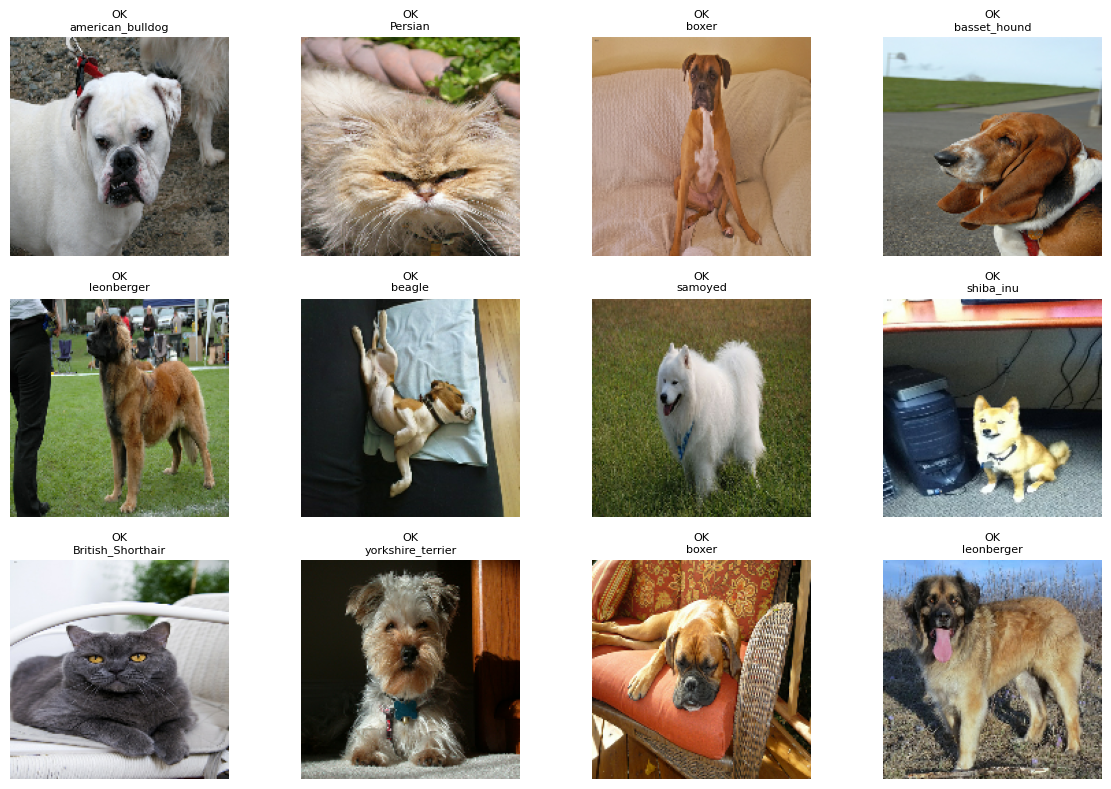

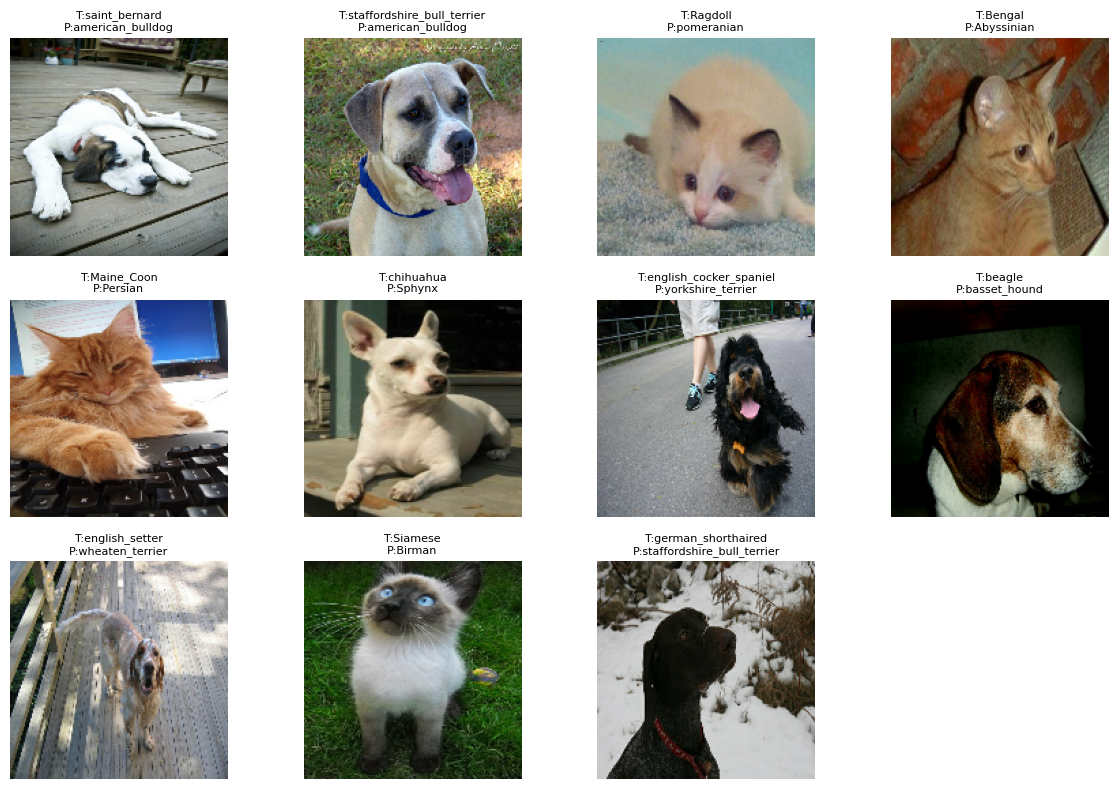

In [20]:
sample_images = []
sample_labels = []

for images, labels in test_ds.take(3):
    sample_images.append(images)
    sample_labels.append(labels)

sample_images = tf.concat(sample_images, axis=0)
sample_labels = tf.concat(sample_labels, axis=0)

preds = model.predict(sample_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)

correct = np.where(pred_classes == sample_labels.numpy())[0]
wrong = np.where(pred_classes != sample_labels.numpy())[0]

plt.figure(figsize=(12,8))
for i, idx in enumerate(correct[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img,0,1))
    plt.title(f"OK\n{label_names[int(pred_classes[idx])]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
for i, idx in enumerate(wrong[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img,0,1))
    t = label_names[int(sample_labels[idx])]
    p = label_names[int(pred_classes[idx])]
    plt.title(f"T:{t}\nP:{p}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8) Matriz de confusión (bonus recomendable)


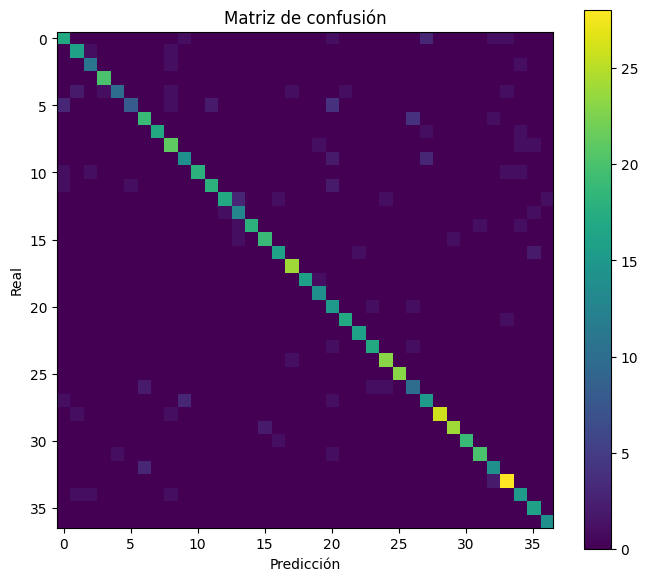

In [21]:
all_preds = []
all_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.append(np.argmax(preds, axis=1))
    all_true.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

cm = tf.math.confusion_matrix(all_true, all_preds, num_classes=num_classes).numpy()

plt.figure(figsize=(8,7))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.show()

## 9) Guardar modelo
Usa un nombre que incluya tu equipo o usuario.


In [22]:
model.save("semana3_pro_equipoXX_transfer_learning.keras")

## 10) Reflexión final (obligatoria)
Responde en 10–15 líneas:
- ¿Qué ventaja viste en usar transfer learning frente a entrenar desde cero?
La principal ventaja, es que te ahorra mucho tiempo de estar programandola y repitiendo una y otra vez si esta haciendolo bien a demás que no te puedes equivocar al crearla porque ya está creada.

- ¿Qué diferencia observaste entre feature extraction y fine-tuning?
En feature extraction, se congelan las capas del modelo preentrenado y solo se entrena la capa final mientras que en fine tuning de descongelan varias capas haciendo que tenga un inicio invariable pero que se puedan adaptar las capas finales a la nueva tarea, aunque duré mas tiempo y requiera más datos

- ¿Qué limitaciones tendría este modelo si lo aplicas a sprites, enemigos o criaturas de un videojuego real?
Que como son sprites tienen una peor resolucion lo que podría llegar a dar problomas porque no detecte ese estilo de diseño.
Por ejemlo si entrenas una ia con imagenes reales si luego le pones pixel art no va a ser tan distinguible para la ia.